Explores the possibilties of using two different thresholds -- one for regular slices and for edge slices -- and measuring performance this way. This produces a heatmap, where the axes are the thresholds for middle / edge slices respectively, and the color is the resulting accuracy of the model 

In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
from sklearn.metrics import roc_auc_score

In [43]:
test_dir = 'outputs_edges/regular1'
run_num = 0
model_name = 'model_auc'

test_dir = Path('/data/vision/polina/users/marcusbl/bin_class') / test_dir


In [44]:
# Download the full samples DF for cross-reference to the results
full_samples_df = pd.read_csv('/data/vision/polina/users/marcusbl/all_data/samples.csv', index_col = 0)

# Downlaod the results dataframe for predictions
downloaded_results_df = pd.read_csv(test_dir / f'run{run_num}' / 'test_info' / f'{model_name}_raw.csv', index_col = 0)

Merge and add progress bar

In [45]:
results_df = pd.merge(left = downloaded_results_df, right = full_samples_df, how = 'left', on = ['pdf_num', 'stack_num', 'scan_num', 'path'])
results_df.head(5)

min_labeled = results_df['labeled_scans'].apply(ast.literal_eval).apply(min)
max_labeled = results_df['labeled_scans'].apply(ast.literal_eval).apply(max)
results_df['progress'] = (results_df['scan_num'] - min_labeled) / (max_labeled - min_labeled)
bins = np.linspace(0, 1, 11)
results_df["bin"] = pd.cut(results_df['progress'], bins = bins, include_lowest=True)

results_df.head()

,preds,probs,labels,idxs,pdf_num,stack_num,path,scan_num,mask_path,type,person,person_id,dataset,labeled_scans,num_scans,label,progress,bin
0,1,0.925717,1,0,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,0,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.000000,"(-0.001, 0.1]"
1,1,0.901681,1,1,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,1,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.030303,"(-0.001, 0.1]"
2,1,0.939635,1,2,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,2,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.060606,"(-0.001, 0.1]"
3,1,0.756428,1,3,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,3,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.090909,"(-0.001, 0.1]"
4,0,0.259910,1,4,1,2,/data/vision/polina/users/mfirenze/Data_sharin...,4,/data/vision/polina/users/mfirenze/Data_sharin...,sag,MAP-C517/MR-EI_Fetal_Body-25010838-20170829,7,BCH,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",36,1,0.121212,"(0.1, 0.2]"


In [46]:
results_df['bin'].value_counts()

bin
(-0.001, 0.1]    217
(0.9, 1.0]       204
(0.3, 0.4]       184
(0.4, 0.5]       181
(0.7, 0.8]       178
(0.6, 0.7]       178
(0.1, 0.2]       175
(0.8, 0.9]       170
(0.2, 0.3]       169
(0.5, 0.6]       168
Name: count, dtype: int64

We assume that we can be more lenient with edge slices than with main slices, so we want to predict positively less often for edges than for the middle:

t_edge >= t_middle (or j >= i)

In [47]:
edge_cats = results_df['bin'].cat.categories[0], results_df['bin'].cat.categories[-1]
is_edge = results_df['bin'].isin(edge_cats)

In [101]:
thresholds = np.linspace(0, 1, 11)
n = len(thresholds)

results = np.zeros((n, n, 2))

labels = results_df['labels']
is_pos = labels == 1
is_neg = labels == 0

for i, t_middle in enumerate(thresholds):
    for j, t_edge in enumerate(thresholds):
        if j < i:
            results[i, j] = np.nan
            continue
        
        assert t_edge >= t_middle

        preds_edge = is_edge & (results_df['probs'] > t_edge)
        preds_middle = ~is_edge & (results_df['probs'] > t_middle)
        preds = preds_edge | preds_middle

        tp = (is_pos & preds).sum()
        fp = (is_neg & preds).sum()

        results[i, j, 0] = tp / is_pos.sum()
        results[i, j, 1] = fp / is_neg.sum()


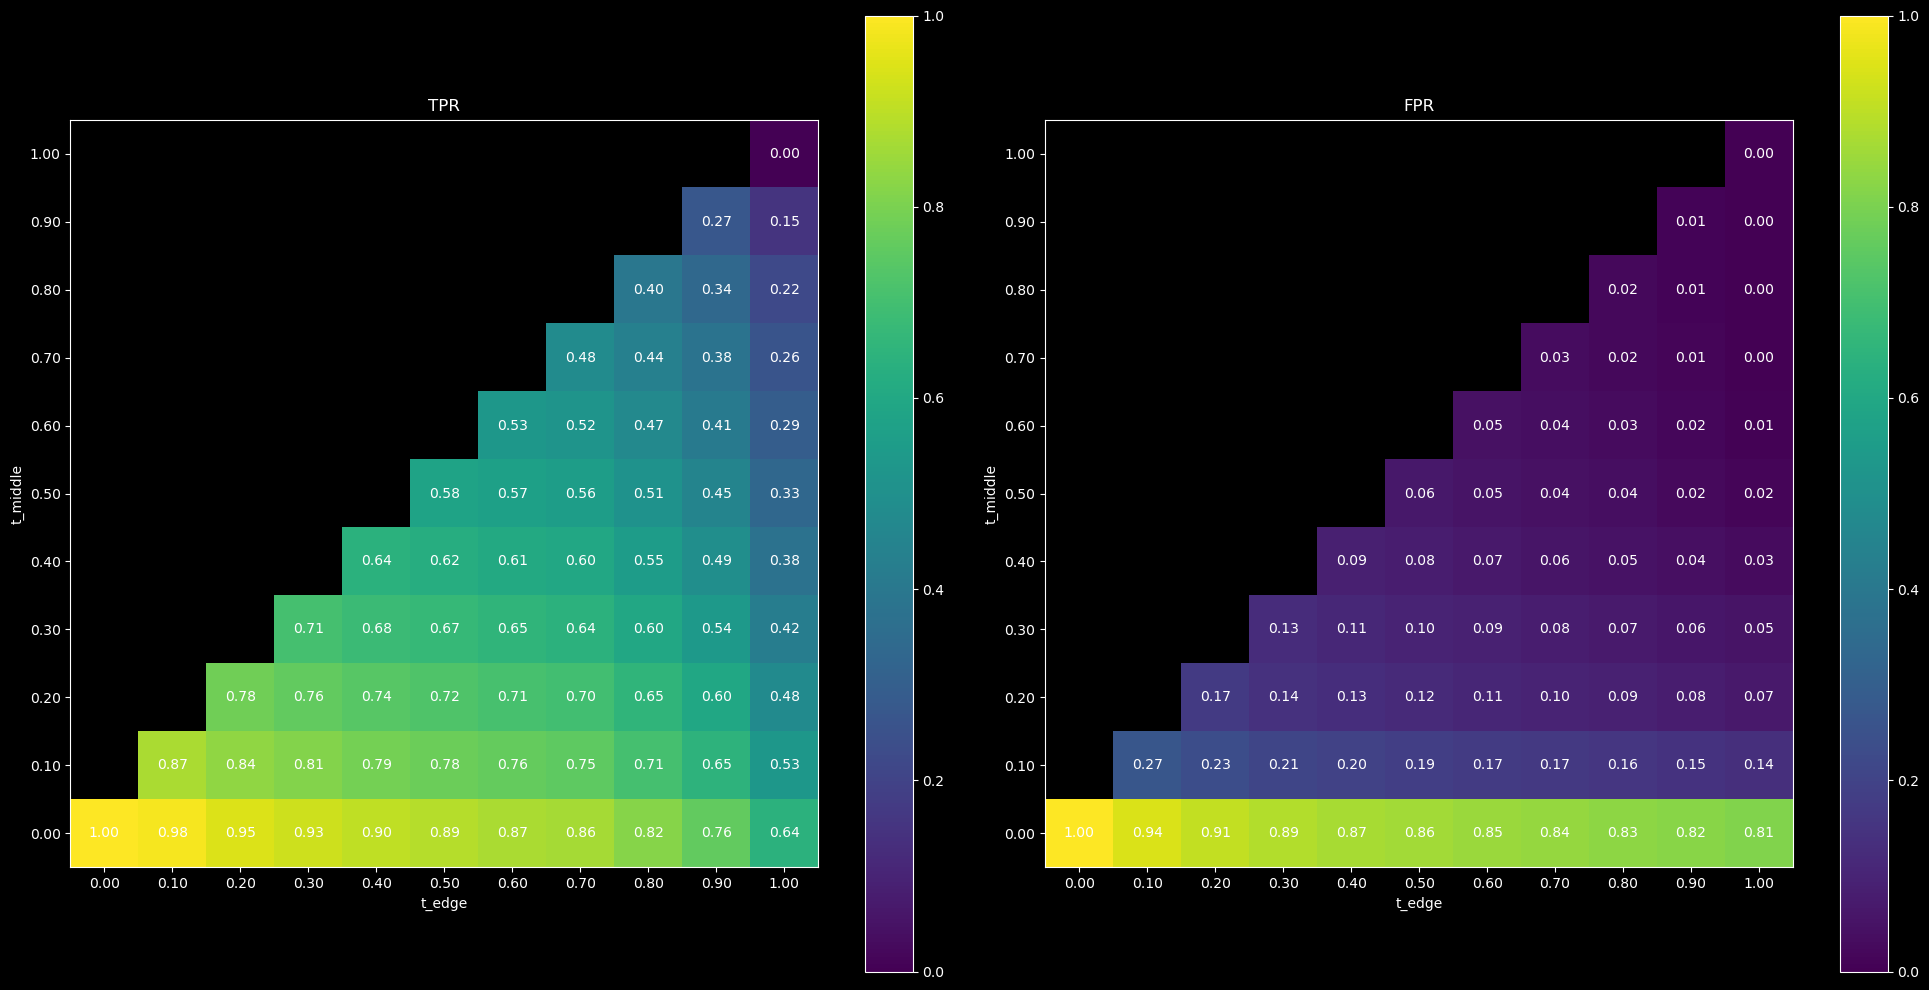

In [102]:
titles = ['TPR', 'FPR']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

for i in range(results.shape[-1]):
    im = axes[i].imshow(results[:, :, i], cmap='viridis', vmin=0, vmax=1)

    axes[i].set_xticks(range(len(thresholds)))
    axes[i].set_yticks(range(len(thresholds)))

    axes[i].set_xticklabels([f'{t:.2f}' for t in thresholds])
    axes[i].set_yticklabels([f'{t:.2f}' for t in thresholds])

    axes[i].set_xlabel('t_edge')
    axes[i].set_ylabel('t_middle')

    axes[i].set_title(titles[i])
    axes[i].invert_yaxis()

    # Add text annotations
    for y in range(results.shape[0]):
        for x in range(results.shape[1]):
            val = results[y, x, i]
            
            if np.isnan(val):
                continue

            axes[i].text(
                x, y,
                f"{val:.2f}",
                ha='center',
                va='center',
                color='white'
            )

    fig.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()


Note that the default is to use the same threshold for both dimensions, which corresponds to the main diagonal here. We want to see if any off-diagonal approaches to better